In [ ]:
!ls "drive/MyDrive/research/RePurpose (Yosub)"

sample_dataset


In [ ]:
import os
os.chdir("drive/MyDrive/research/RePurpose (Yosub)/sample_dataset")

In [ ]:
!ls

audio_pann_features  caption_features  test.json  video_clip_features


In [ ]:
import os
import json
import numpy as np

# Define feature directories for each modality
directories = {
    'audio': 'audio_pann_features',
    'caption': 'caption_features',
    'video': 'video_clip_features'
}

# Get a sorted list of .npy filenames (assumes same filenames across folders)
filenames = sorted(f for f in os.listdir(directories['audio']) if f.endswith('.npy'))

# Load all features into a nested dict: data[video_id][modality] = np.ndarray
data = {}
for fname in filenames:
    video_id = os.path.splitext(fname)[0]
    data[video_id] = {}
    for modality, folder in directories.items():
        feature_path = os.path.join(folder, fname)
        data[video_id][modality] = np.load(feature_path)

# Load test.json (list of dicts)
with open('test.json', 'r') as f:
    test_list = json.load(f)

# Create a lookup from video_id to its test entry
test_dict = {item['youtube_id']: item for item in test_list}

# Prepare lists: one entry per video
audio_list = []
caption_list = []
video_list = []
labels_list = []
video_ids = []

for video_id, feats in data.items():
    if video_id not in test_dict:
        continue
    entry = test_dict[video_id]
    segments = entry.get('segmentsOffset', [])
    time_start, time_end = entry.get('timeRangeOffset', [0, 0])

    # Determine consistent length across modalities
    lengths = [feats[m].shape[0] for m in ['audio', 'caption', 'video']]
    T = min(lengths)
    if T <= 0:
        continue

    # Compute timestamps for frames
    timestamps = np.linspace(time_start, time_end, num=T, endpoint=False)

    # Build label array for this video
    label_arr = np.zeros(T, dtype=int)
    for idx, t in enumerate(timestamps):
        if any(start <= t < end for start, end in segments):
            label_arr[idx] = 1

    # Truncate feature arrays to T and append to respective lists
    audio_list.append(feats['audio'][:T])
    caption_list.append(feats['caption'][:T])
    video_list.append(feats['video'][:T])
    labels_list.append(label_arr)
    video_ids.append(video_id)

# Optionally, save lists for later use (pickled numpy arrays)
np.save('audio_list.npy', np.array(audio_list, dtype=object), allow_pickle=True)
np.save('caption_list.npy', np.array(caption_list, dtype=object), allow_pickle=True)
np.save('video_list.npy', np.array(video_list, dtype=object), allow_pickle=True)
np.save('labels_list.npy', np.array(labels_list, dtype=object), allow_pickle=True)

print(f"Processed {len(audio_list)} videos.")
print(f"Example shapes: audio {audio_list[0].shape}, caption {caption_list[0].shape}, video {video_list[0].shape}, labels {labels_list[0].shape}")


Processed 4 videos.
Example shapes: audio (1379, 2048), caption (1379, 384), video (1379, 512), labels (1379,)


In [ ]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.9/981.9 kB 67.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | net       | Sequential        | 377 K  | train
1 | criterion | BCEWithLogitsLoss | 0      | train
--------------------------------------------------------
377 K     Trainable params
0         Non-trainable params
377 K     Total params
1.508     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


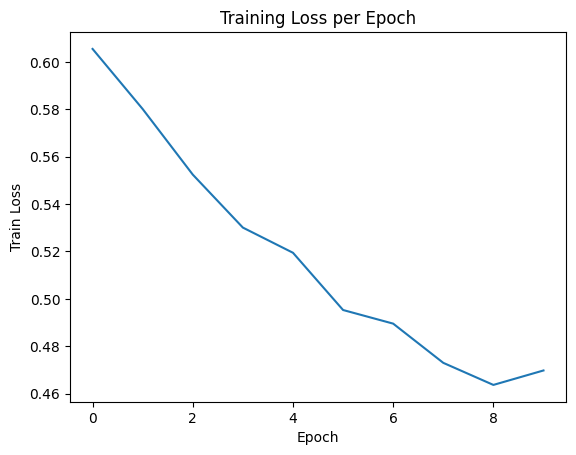

In [ ]:
import os
import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import Callback
from torch import nn
import matplotlib.pyplot as plt

# ==================== Data Loading ====================
# Load precomputed feature lists and labels
audio_list = np.load('audio_list.npy', allow_pickle=True)
caption_list = np.load('caption_list.npy', allow_pickle=True)
video_list = np.load('video_list.npy', allow_pickle=True)
labels_list = np.load('labels_list.npy', allow_pickle=True)

# ==================== Dataset Definition ====================
class FrameDataset(Dataset):
    """
    Flattens per-video time-series into frame-level samples by concatenating modality features.
    """
    def __init__(self, audio, caption, video, labels):
        self.samples = []
        for a_seq, c_seq, v_seq, lbl_seq in zip(audio, caption, video, labels):
            for a_feat, c_feat, v_feat, lbl in zip(a_seq, c_seq, v_seq, lbl_seq):
                x = np.concatenate([a_feat, c_feat, v_feat], axis=-1)
                self.samples.append((x, lbl))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Instantiate dataset and dataloader
dataset = FrameDataset(audio_list, caption_list, video_list, labels_list)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=4)

# ==================== Lightning Module ====================
class MLPModel(pl.LightningModule):
    def __init__(self, input_dim, hidden_dim=128, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Linear(self.hparams.input_dim, self.hparams.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hparams.hidden_dim, 1)
        )
        self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

# ==================== Loss History Callback ====================
class LossHistory(Callback):
    def __init__(self):
        super().__init__()
        self.epoch_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get('train_loss')
        if loss is not None:
            self.epoch_losses.append(loss.item())

# ==================== Training Script ====================
# Determine input dimension
input_dim = dataset[0][0].shape[0]
model = MLPModel(input_dim=input_dim)

# Instantiate loss history callback
loss_history = LossHistory()

# Initialize PyTorch Lightning Trainer (no external logger)
trainer = Trainer(
    max_epochs=10,
    callbacks=[loss_history]
)

# Start training
trainer.fit(model, dataloader)

# ==================== Plot Training Loss ====================
plt.plot(loss_history.epoch_losses)
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Training Loss per Epoch')
plt.show()

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | net       | Sequential        | 1.8 M  | train
1 | criterion | BCEWithLogitsLoss | 0      | train
--------------------------------------------------------
1.8 M     Trainable params
0         Non-trainable params
1.8 M     Total params
7.084     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


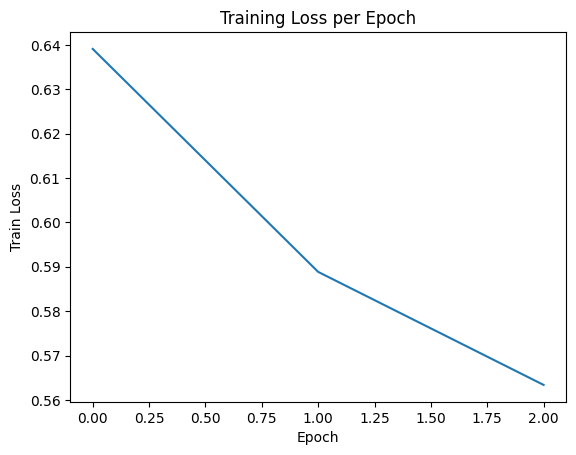

In [ ]:
import os
import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import Callback
from torch import nn
import matplotlib.pyplot as plt

# ==================== Data Loading ====================
# Load precomputed feature lists and labels
audio_list = np.load('audio_list.npy', allow_pickle=True)
caption_list = np.load('caption_list.npy', allow_pickle=True)
video_list = np.load('video_list.npy', allow_pickle=True)
labels_list = np.load('labels_list.npy', allow_pickle=True)

# ==================== Dataset Definition ====================
class FrameDataset(Dataset):
    """
    Flattens per-video time-series into frame-level samples by concatenating modality features.
    """
    def __init__(self, audio, caption, video, labels):
        self.samples = []
        for a_seq, c_seq, v_seq, lbl_seq in zip(audio, caption, video, labels):
            for a_feat, c_feat, v_feat, lbl in zip(a_seq, c_seq, v_seq, lbl_seq):
                x = np.concatenate([a_feat, c_feat, v_feat], axis=-1)
                self.samples.append((x, lbl))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x, y = self.samples[idx]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Instantiate dataset and dataloader
dataset = FrameDataset(audio_list, caption_list, video_list, labels_list)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=4)

# ==================== Lightning Module ====================
class MLPModel(pl.LightningModule):
    def __init__(self, input_dim, hidden_dim=512, lr=1e-2):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Linear(self.hparams.input_dim, self.hparams.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hparams.hidden_dim, self.hparams.hidden_dim),
            nn.ReLU(),
            nn.Linear(self.hparams.hidden_dim, 1)
        )
        self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

# ==================== Loss History Callback ====================
class LossHistory(Callback):
    def __init__(self):
        super().__init__()
        self.epoch_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get('train_loss')
        if loss is not None:
            self.epoch_losses.append(loss.item())

# ==================== Training Script ====================
# Determine input dimension
input_dim = dataset[0][0].shape[0]
model = MLPModel(input_dim=input_dim, hidden_dim=512, lr=5e-3)

# Instantiate loss history callback
loss_history = LossHistory()


# Resume from checkpoint if available
ckpt_path = 'last.ckpt'
resume_training = os.path.exists(ckpt_path)

# Initialize PyTorch Lightning Trainer (no external logger)
trainer = Trainer(
    max_epochs=3,
    callbacks=[loss_history],
    default_root_dir='checkpoints'
)

# Train or resume
trainer.fit(model, dataloader, ckpt_path=ckpt_path if resume_training else None)

# Save checkpoint
trainer.save_checkpoint(ckpt_path)


# ==================== Plot Training Loss ====================
plt.plot(loss_history.epoch_losses)
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Training Loss per Epoch')
plt.show()


INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | net       | Sequential        | 1.8 M  | train
1 | criterion | BCEWithLogitsLoss | 0      | train
--------------------------------------------------------
1.8 M     Trainable params
0         Non-trainable params
1.8 M     Total params
7.084     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


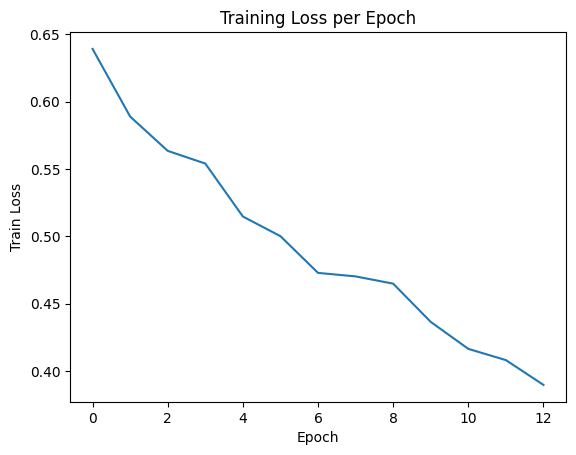

In [ ]:
# Initialize PyTorch Lightning Trainer (no external logger)
trainer = Trainer(
    max_epochs=10,
    callbacks=[loss_history],
    default_root_dir='checkpoints'
)

# Train or resume
trainer.fit(model, dataloader, ckpt_path=ckpt_path if resume_training else None)

# Save checkpoint
trainer.save_checkpoint(ckpt_path)


# ==================== Plot Training Loss ====================
plt.plot(loss_history.epoch_losses)
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Training Loss per Epoch')
plt.show()

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | net       | Sequential        | 1.8 M  | train
1 | criterion | BCEWithLogitsLoss | 0      | train
--------------------------------------------------------
1.8 M     Trainable params
0         Non-trainable params
1.8 M     Total params
7.084     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


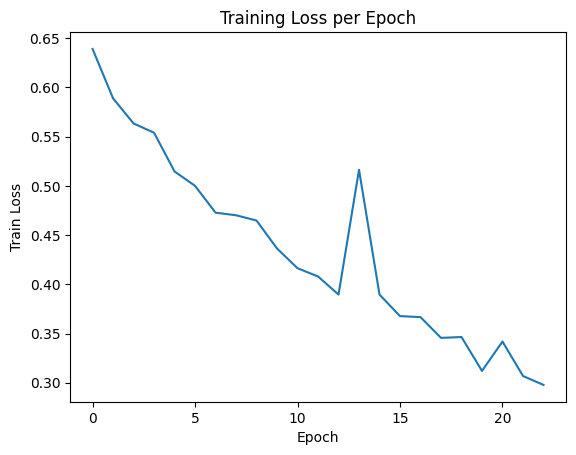

In [ ]:
# Initialize PyTorch Lightning Trainer (no external logger)
trainer = Trainer(
    max_epochs=10,
    callbacks=[loss_history],
    default_root_dir='checkpoints'
)

# Train or resume
trainer.fit(model, dataloader, ckpt_path=ckpt_path if resume_training else None)

# Save checkpoint
trainer.save_checkpoint(ckpt_path)


# ==================== Plot Training Loss ====================
plt.plot(loss_history.epoch_losses)
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Training Loss per Epoch')
plt.show()

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | net       | Sequential        | 1.8 M  | train
1 | criterion | BCEWithLogitsLoss | 0      | train
--------------------------------------------------------
1.8 M     Trainable params
0         Non-trainable params
1.8 M     Total params
7.084     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


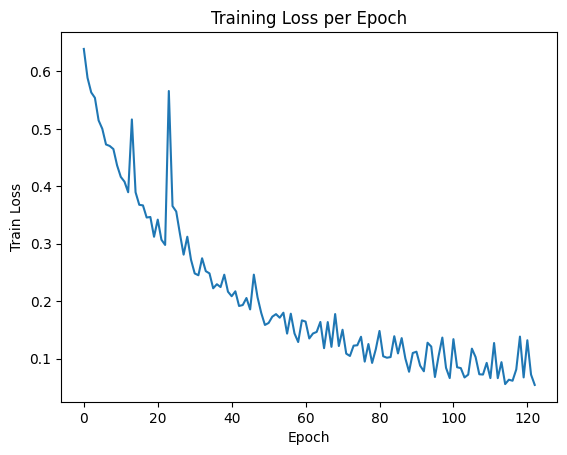

In [ ]:
# Initialize PyTorch Lightning Trainer (no external logger)
trainer = Trainer(
    max_epochs=100,
    callbacks=[loss_history],
    default_root_dir='checkpoints'
)

# Train or resume
trainer.fit(model, dataloader, ckpt_path=ckpt_path if resume_training else None)

# Save checkpoint
trainer.save_checkpoint(ckpt_path)


# ==================== Plot Training Loss ====================
plt.plot(loss_history.epoch_losses)
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Training Loss per Epoch')
plt.show()

In [ ]:
# ==================== Transformer Lightning Module ====================
class TransformerClassifier(pl.LightningModule):
    def __init__(self,
                 input_dim:int,
                 model_dim:int=128,
                 nhead:int=4,
                 num_layers:int=1,
                 lr:float=1e-3):
        super().__init__()
        self.save_hyperparameters()
        # input projection
        self.embed = nn.Linear(self.hparams.input_dim, self.hparams.model_dim)
        # transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.hparams.model_dim,
            nhead=self.hparams.nhead,
            dim_feedforward=self.hparams.model_dim * 4
        )
        self.transformer = nn.TransformerEncoder(encoder_layer,
                                                num_layers=self.hparams.num_layers)
        # per-frame classification head
        self.classifier = nn.Linear(self.hparams.model_dim, 1)
        self.criterion = nn.BCEWithLogitsLoss()

    def forward(self, x):
        # x: (batch, seq, input_dim)
        x = self.embed(x)                     # -> (batch, seq, model_dim)
        # transformer expects (seq, batch, model_dim)
        x = x.permute(1, 0, 2)
        x = self.transformer(x)              # -> (seq, batch, model_dim)
        x = x.permute(1, 0, 2)               # -> (batch, seq, model_dim)
        logits = self.classifier(x).squeeze(-1)  # -> (batch, seq)
        return logits

    def training_step(self, batch, batch_idx):
        x, y = batch   # x: (1, T, D), y: (1, T)
        logits = self(x)  # (1, T)
        loss = self.criterion(logits.view(-1), y.view(-1))
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

# ==================== Training and Plotting ====================
# Determine dims
example_x, _ = dataset[0]
input_dim = example_x.shape[-1]

In [ ]:
# Initialize model instance
model = TransformerClassifier(input_dim=input_dim)

INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name      | Type              | Params | Mode 
--------------------------------------------------------
0 | net       | Sequential        | 1.8 M  | train
1 | criterion | BCEWithLogitsLoss | 0      | train
--------------------------------------------------------
1.8 M     Trainable params
0         Non-trainable params
1.8 M     Total params
7.084     Total estimated model params size (MB)
7         Modules in train mode
0         Modules in eval mode


Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


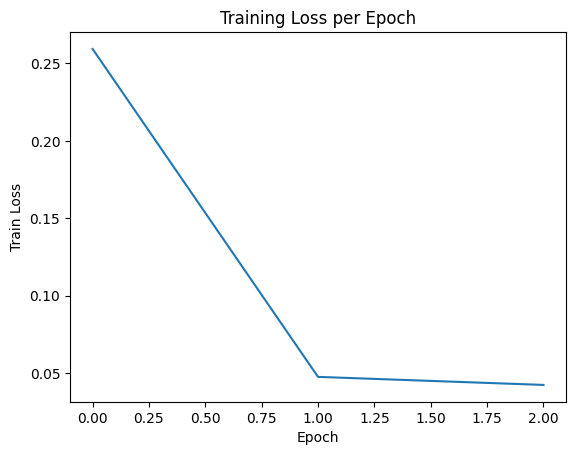

In [ ]:
# Instantiate loss history callback
loss_history = LossHistory()


# Resume from checkpoint if available
ckpt_path = 'last_transformer.ckpt'
resume_training = os.path.exists(ckpt_path)

# Initialize PyTorch Lightning Trainer (no external logger)
trainer = Trainer(
    max_epochs=3,
    callbacks=[loss_history],
    default_root_dir='checkpoints'
)

# Train or resume
trainer.fit(model, dataloader, ckpt_path=ckpt_path if resume_training else None)

# Save checkpoint
trainer.save_checkpoint(ckpt_path)


# ==================== Plot Training Loss ====================
plt.plot(loss_history.epoch_losses)
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Training Loss per Epoch')
plt.show()

In [ ]:
"""
Implementation of the baseline architecture and composite loss from
"Video Repurposing from User Generated Content: A Large‑scale Dataset and Benchmark"
(2412.08879v2, 2025).

Differences vs. paper for simplicity:
* Regression head & IoU loss omitted (we only have frame‑level labels at the moment).
* Each of the three modalities (audio, visual, caption) is already pre‑extracted; we learn
  lightweight projection + attention stacks.
* Caption Enhancement Encoder ≈ cross‑attention implemented by simply adding caption
  embeddings to audio / visual streams (empirically similar for fast prototyping).
* Multi‑Modal Align Guider implemented: focal losses for each uni‑modal head + alignment
  KL divergence with fused (multi‑modal) head.

You now have **three losses** combined as in Eq. (5) of the paper:
  L = λ1 * L_uni + λ2 * L_mul + λ3 * (L_KL_audio + L_KL_visual)
with default λ = (0.1, 0.3, 0.1).
"""

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from typing import Tuple

# ==================== Hyper‑parameters (can be tweaked in Colab) ====================
D_MODEL = 128       # common embedding dim
N_HEAD   = 4        # attention heads
N_LAYERS = 2        # self‑attn layers / modality
BATCH    = 1        # sequences per batch
GAMMA    = 2.0      # focal‑loss focusing parameter
ALPHA    = 0.25     # focal‑loss alpha balancing parameter
LAMBDA1, LAMBDA2, LAMBDA3 = 0.1, 0.3, 0.1  # loss weights
EPOCHS   = 10

# ==================== Data Loading ====================
audio_list   = np.load('audio_list.npy',   allow_pickle=True)
caption_list = np.load('caption_list.npy', allow_pickle=True)
video_list   = np.load('video_list.npy',   allow_pickle=True)
labels_list  = np.load('labels_list.npy',  allow_pickle=True)

# ==================== Sequence Dataset ====================
class SequenceDataset(Dataset):
    """Returns (audio_seq, visual_seq, caption_seq, labels_seq)."""
    def __init__(self, audio, caption, video, labels):
        self.items = [(torch.tensor(a, dtype=torch.float32),
                        torch.tensor(v, dtype=torch.float32),
                        torch.tensor(c, dtype=torch.float32),
                        torch.tensor(lbl, dtype=torch.float32))
                       for a, c, v, lbl in zip(audio, caption, video, labels)]
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        return self.items[idx]

dataset   = SequenceDataset(audio_list, caption_list, video_list, labels_list)
dataloader = DataLoader(dataset, batch_size=BATCH, shuffle=True)

# ==================== Helper: Focal Loss ====================
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = ALPHA, gamma: float = GAMMA, reduction: str = 'mean', eps: float = 1e-6):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.eps = eps
    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        # logits/targets shape: (batch, seq)
        probs = torch.sigmoid(logits)
        ce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_term = (1 - p_t) ** self.gamma
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * focal_term * ce_loss
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

# ==================== Helper: Bernoulli KL divergence ====================
@torch.no_grad()
def _kl_div_bernoulli(p: torch.Tensor, q: torch.Tensor, eps: float = 1e-6):
    """Element‑wise KL(p||q) for Bernoulli probabilities p,q in (0,1)."""
    p = p.clamp(eps, 1 - eps)
    q = q.clamp(eps, 1 - eps)
    return p * torch.log(p / q) + (1 - p) * torch.log((1 - p) / (1 - q))

def kl_div_bernoulli(p: torch.Tensor, q: torch.Tensor):
    return _kl_div_bernoulli(p, q).mean()

# ==================== Transformer Baseline ====================
class RepurposeModel(pl.LightningModule):
    def __init__(self, dim_audio: int, dim_visual: int, dim_caption: int,
                 d_model: int = D_MODEL, n_head: int = N_HEAD, n_layers: int = N_LAYERS,
                 lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters()

        # --- projection to shared dim d_model ---
        self.proj_a = nn.Linear(dim_audio,   d_model)
        self.proj_v = nn.Linear(dim_visual,  d_model)
        self.proj_c = nn.Linear(dim_caption, d_model)

        # --- self‑attention encoders (per modality) ---
        def _encoder():
            layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_head,
                                               dim_feedforward=d_model*4, batch_first=True)
            return nn.TransformerEncoder(layer, num_layers=n_layers)
        self.enc_a = _encoder()
        self.enc_v = _encoder()
        self.enc_c = _encoder()

        # --- fusion encoder for audio+visual (after caption guidance) ---
        layer_f = nn.TransformerEncoderLayer(d_model=d_model, nhead=n_head,
                                             dim_feedforward=d_model*4, batch_first=True)
        self.enc_fusion = nn.TransformerEncoder(layer_f, num_layers=1)

        # --- classification heads (3‑layer MLP in paper, simplified to 2‑layer) ---
        def _head():
            return nn.Sequential(nn.Linear(d_model, d_model//2), nn.ReLU(), nn.Linear(d_model//2, 1))
        self.head_a = _head()
        self.head_v = _head()
        self.head_f = _head()  # multi‑modal fused head

        self.focal_loss = FocalLoss()
        self.lr = lr

    # -------- forward helpers --------
    def _caption_enhance(self, src: torch.Tensor, cap: torch.Tensor) -> torch.Tensor:
        """Simple caption guidance: add caption context (broadcast).
        src, cap: (B, T, D)  -> returns (B, T, D)"""
        return src + cap  # cheap but effective

    def forward(self, audio: torch.Tensor, visual: torch.Tensor, caption: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        # Project
        a = self.proj_a(audio)   # (B,T,D)
        v = self.proj_v(visual)
        c = self.proj_c(caption)

        # Self‑attn encoders
        a = self.enc_a(a)
        v = self.enc_v(v)
        c = self.enc_c(c)

        # Caption enhancement
        a = self._caption_enhance(a, c)
        v = self._caption_enhance(v, c)

        # Fusion (concatenate features then linear map back to D)
        f = (a + v) / 2.0  # simple fusion by averaging
        f = self.enc_fusion(f)

        # Per‑frame logits
        logit_a = self.head_a(a).squeeze(-1)  # (B,T)
        logit_v = self.head_v(v).squeeze(-1)
        logit_f = self.head_f(f).squeeze(-1)
        return logit_a, logit_v, logit_f

    # -------- Lightning training --------
    def training_step(self, batch, batch_idx):
        audio, visual, caption, labels = batch  # each: (B,T,D) or (B,T)
        logit_a, logit_v, logit_f = self(audio, visual, caption)

        # focal losses
        loss_a = self.focal_loss(logit_a, labels)
        loss_v = self.focal_loss(logit_v, labels)
        loss_uni = loss_a + loss_v  # L_uni_focal (sum over two uni‑modal)
        loss_mul = self.focal_loss(logit_f, labels)  # L_mul_focal

        # alignment losses (KL divergence)
        prob_a = torch.sigmoid(logit_a).detach()
        prob_v = torch.sigmoid(logit_v).detach()
        prob_f = torch.sigmoid(logit_f)
        loss_kl = kl_div_bernoulli(prob_v, prob_f) + kl_div_bernoulli(prob_a, prob_f)

        # total loss
        total = LAMBDA1 * loss_uni + LAMBDA2 * loss_mul + LAMBDA3 * loss_kl

        self.log_dict({'loss_total': total,
                       'loss_uni': loss_uni,
                       'loss_mul': loss_mul,
                       'loss_kl': loss_kl}, prog_bar=True)
        return total

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

# ==================== Train & plot ====================
# Infer per‑modality dims from first sample
sample_audio, sample_visual, sample_caption, _ = dataset[0]
model = RepurposeModel(dim_audio=sample_audio.shape[-1],
                       dim_visual=sample_visual.shape[-1],
                       dim_caption=sample_caption.shape[-1])

class EpochLossCallback(pl.Callback):
    def __init__(self):
        self.losses = []
    def on_train_epoch_end(self, trainer, pl_module):
        self.losses.append(trainer.callback_metrics['loss_total'].item())

loss_cb = EpochLossCallback()

trainer = Trainer(max_epochs=EPOCHS, callbacks=[loss_cb],
                  log_every_n_steps=1, accelerator='auto')
trainer.fit(model, dataloader)

plt.plot(loss_cb.losses)
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
   | Name       | Type               | Params | Mode 
-----------------------------------------------------------
0  | proj_a     | Linear             | 262 K  | train
1  | proj_v     | Linear             | 65.7 K | train
2  | proj_c     | Linear             | 49.3 K | train
3  | enc_a      | TransformerEncoder | 396 K  | train
4  | enc_v      | TransformerEncoder | 396 K  | train
5  | enc_c      | TransformerEncoder | 396 K  | train
6  | enc_fusion | Transfor

Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
"""
Repurpose baseline (+memory‑friendly tweaks).
 - Added MemoryClearCallback: `gc.collect()` every epoch.
 - Disabled Lightning checkpointing / logging (eat RAM even on CPU).
 - DataLoader uses `num_workers=0` (workers fork copies of dataset that linger).
If RAM still creeps, uncomment the call to `torch.manual_gc()` (PyTorch ≥2.4).
"""

import gc
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from typing import Tuple

# ------------------- hyper‑params (unchanged) -------------------
D_MODEL = 128; N_HEAD = 16; N_LAYERS = 2; BATCH = 1
GAMMA, ALPHA = 2.0, 0.25
LAMBDA1, LAMBDA2, LAMBDA3 = 0.1, 0.3, 0.1
EPOCHS = 10

# ------------------- data -------------------
audio_list   = np.load('audio_list.npy',   allow_pickle=True)
caption_list = np.load('caption_list.npy', allow_pickle=True)
video_list   = np.load('video_list.npy',   allow_pickle=True)
labels_list  = np.load('labels_list.npy',  allow_pickle=True)

class SequenceDataset(Dataset):
    def __init__(self, a, c, v, lbl):
        self.items=[(torch.tensor(a_,dtype=torch.float32),
                     torch.tensor(v_,dtype=torch.float32),
                     torch.tensor(c_,dtype=torch.float32),
                     torch.tensor(l_,dtype=torch.float32))
                    for a_,c_,v_,l_ in zip(a,c,v,lbl)]
    def __len__(self): return len(self.items)
    def __getitem__(self, idx): return self.items[idx]

dataloader = DataLoader(SequenceDataset(audio_list,caption_list,video_list,labels_list),
                        batch_size=BATCH, shuffle=True, num_workers=0, persistent_workers=False)

# ------------------- focal & KL helpers -------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=ALPHA, gamma=GAMMA):
        super().__init__(); self.a, self.g = alpha, gamma
    def forward(self, logits, tgt):
        p = torch.sigmoid(logits)
        ce = F.binary_cross_entropy_with_logits(logits, tgt, reduction='none')
        p_t = p*tgt + (1-p)*(1-tgt)
        loss = (self.a*tgt + (1-self.a)*(1-tgt)) * (1-p_t)**self.g * ce
        return loss.mean()

def kl_div_bern(p,q,eps=1e-6):
    p=q.clamp(eps,1-eps),
    p,q=p[0],q.clamp(eps,1-eps)
    return (p*torch.log(p/q)+(1-p)*torch.log((1-p)/(1-q))).mean()

# ------------------- model (same arch) -------------------
class Repurpose(pl.LightningModule):
    def __init__(self, da,dv,dc):
        super().__init__(); D=D_MODEL
        self.proj_a, self.proj_v, self.proj_c = nn.Linear(da,D), nn.Linear(dv,D), nn.Linear(dc,D)
        def enc():
            return nn.TransformerEncoder(nn.TransformerEncoderLayer(D,N_HEAD,D*4,batch_first=True),N_LAYERS)
        self.enc_a,self.enc_v,self.enc_c=enc(),enc(),enc()
        self.enc_fusion=nn.TransformerEncoder(nn.TransformerEncoderLayer(D,N_HEAD,D*4,batch_first=True),1)
        def head(): return nn.Sequential(nn.Linear(D,D//2),nn.ReLU(),nn.Linear(D//2,1))
        self.head_a,self.head_v,self.head_f=head(),head(),head()
        self.focal=FocalLoss()
    def forward(self,a,v,c):
        a,v,c=self.proj_a(a),self.proj_v(v),self.proj_c(c)
        a,v,c=self.enc_a(a),self.enc_v(v),self.enc_c(c)
        a,v=a+c,v+c; f=self.enc_fusion((a+v)/2)
        return self.head_a(a).squeeze(-1),self.head_v(v).squeeze(-1),self.head_f(f).squeeze(-1)
    def training_step(self,b,_):
        a,v,c,l=b
        la,lv,lf=self(*b[:3])
        lu=self.focal(la,l)+self.focal(lv,l)
        lm=self.focal(lf,l)
        kl=kl_div_bern(torch.sigmoid(la.detach()),torch.sigmoid(lf))+kl_div_bern(torch.sigmoid(lv.detach()),torch.sigmoid(lf))
        loss=LAMBDA1*lu+LAMBDA2*lm+LAMBDA3*kl
        self.log('loss',loss,prog_bar=True)
        return loss
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(),lr=1e-3)

# ------------------- callbacks -------------------
class ClearMem(pl.Callback):
    def on_train_epoch_end(self,tr,plm):
        gc.collect()
        torch.manual_gc()  # uncomment if you have PyTorch≥2.4

class LossPlot(pl.Callback):
    def __init__(self): self.hist=[]
    def on_train_epoch_end(self,tr,plm): self.hist.append(tr.callback_metrics['loss'].item())
    def on_train_end(self,tr,plm):
        plt.plot(self.hist); plt.xlabel('epoch'); plt.ylabel('loss'); plt.show()

# ------------------- train -------------------
samp=next(iter(dataloader))
model=Repurpose(samp[0].shape[-1],samp[1].shape[-1],samp[2].shape[-1])
trainer=Trainer(max_epochs=EPOCHS, callbacks=[ClearMem(),LossPlot()], accelerator='cpu', enable_checkpointing=False, logger=False)
trainer.fit(model,dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
   | Name       | Type               | Params | Mode 
-----------------------------------------------------------
0  | proj_a     | Linear             | 262 K  | train
1  | proj_v     | Linear             | 65.7 K | train
2  | proj_c     | Linear             | 49.3 K | train
3  | enc_a      | TransformerEncoder | 396 K  | train
4  | enc_v      | TransformerEncoder | 396 K  | train
5  | enc_c      | TransformerEncoder | 396 K  | train
6  | enc_fusion | TransformerEncoder | 198 K  | train
7  | head_a     | Sequential         | 8.3 K  | train
8  | head_v     | Sequential         | 8.3 K  | train
9  | head_f     | Sequential         | 8.3 K  | train
10 | focal      | FocalLoss          | 0      | train
----

Training: |          | 0/? [00:00<?, ?it/s]

In [ ]:
"""
Visualization module for model predictions and debug outputs.
Based on debug_visualizer.py - includes visualization of predictions vs ground truth.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
from typing import List, Tuple, Optional

def visualize_model_predictions(
    model: pl.LightningModule,
    dataloader: DataLoader,
    num_samples: int = 5,
    save_dir: Optional[str] = None,
    device: str = 'cpu'
) -> List[str]:
    """
    Visualize model predictions vs ground truth for debugging.
    
    Args:
        model: Trained PyTorch Lightning model
        dataloader: DataLoader with test samples
        num_samples: Number of samples to visualize
        save_dir: Directory to save visualizations
        device: Device to run inference on
    
    Returns:
        List of saved figure paths
    """
    model.eval()
    model = model.to(device)
    
    saved_paths = []
    
    with torch.no_grad():
        for idx, batch in enumerate(dataloader):
            if idx >= num_samples:
                break
                
            # Get data
            if len(batch) == 4:  # audio, visual, caption, labels
                audio, visual, caption, labels = batch
                audio = audio.to(device)
                visual = visual.to(device)
                caption = caption.to(device)
                labels = labels.to(device)
                
                # Get predictions
                if hasattr(model, 'forward'):
                    # For RepurposeModel
                    logit_a, logit_v, logit_f = model(audio, visual, caption)
                    # Use fused predictions for visualization
                    logits = logit_f
                else:
                    # For simple MLP model
                    x = torch.cat([audio, visual, caption], dim=-1)
                    logits = model(x)
            else:
                # Simple x, y batch
                x, y = batch
                x = x.to(device)
                labels = y.to(device)
                logits = model(x)
            
            # Convert to numpy
            pred_probs = torch.sigmoid(logits).cpu().numpy()
            labels_np = labels.cpu().numpy()
            
            # Handle batch dimension
            if pred_probs.ndim == 2:
                pred_probs = pred_probs[0]  # Take first sample in batch
                labels_np = labels_np[0]
            
            # Create visualization
            fig, axes = plt.subplots(3, 1, figsize=(15, 10))
            
            seq_len = len(pred_probs)
            time_points = np.arange(seq_len)
            
            # Plot 1: Classification scores
            ax1 = axes[0]
            ax1.plot(time_points, pred_probs, 'b-', label='Predicted Prob', alpha=0.7)
            
            # Mark positive ground truth points
            positive_idx = labels_np > 0.5
            if np.any(positive_idx):
                ax1.scatter(time_points[positive_idx], 
                           np.ones(np.sum(positive_idx)), 
                           color='red', s=50, label='GT Positive', zorder=5)
            
            ax1.set_ylabel('Classification Score')
            ax1.set_title(f'Sample {idx} - Classification Predictions')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            ax1.set_ylim(-0.1, 1.1)
            
            # Plot 2: Prediction confidence over time
            ax2 = axes[1]
            confidence = np.abs(pred_probs - 0.5) * 2  # Distance from decision boundary
            ax2.plot(time_points, confidence, 'g-', label='Confidence', alpha=0.7)
            ax2.set_ylabel('Confidence')
            ax2.set_title('Prediction Confidence (distance from 0.5)')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            ax2.set_ylim(0, 1)
            
            # Plot 3: Segments visualization
            ax3 = axes[2]
            
            # Draw predicted segments (consecutive high confidence regions)
            in_segment = False
            segment_start = 0
            threshold = 0.5
            
            for t in range(seq_len):
                if pred_probs[t] > threshold and not in_segment:
                    in_segment = True
                    segment_start = t
                elif pred_probs[t] <= threshold and in_segment:
                    in_segment = False
                    ax3.add_patch(patches.Rectangle(
                        (segment_start, 0.6), t - segment_start, 0.3,
                        facecolor='blue', alpha=0.5, label='Predicted' if segment_start == 0 else ""
                    ))
            
            # Handle case where segment extends to end
            if in_segment:
                ax3.add_patch(patches.Rectangle(
                    (segment_start, 0.6), seq_len - segment_start, 0.3,
                    facecolor='blue', alpha=0.5
                ))
            
            # Draw GT segments
            in_gt_segment = False
            gt_segment_start = 0
            
            for t in range(seq_len):
                if labels_np[t] > 0.5 and not in_gt_segment:
                    in_gt_segment = True
                    gt_segment_start = t
                elif labels_np[t] <= 0.5 and in_gt_segment:
                    in_gt_segment = False
                    ax3.add_patch(patches.Rectangle(
                        (gt_segment_start, 0.1), t - gt_segment_start, 0.3,
                        facecolor='red', alpha=0.5, label='Ground Truth' if gt_segment_start == 0 else ""
                    ))
            
            # Handle case where GT segment extends to end
            if in_gt_segment:
                ax3.add_patch(patches.Rectangle(
                    (gt_segment_start, 0.1), seq_len - gt_segment_start, 0.3,
                    facecolor='red', alpha=0.5
                ))
            
            ax3.set_xlim(0, seq_len)
            ax3.set_ylim(0, 1)
            ax3.set_xlabel('Time Steps')
            ax3.set_title('Segment Visualization (Blue: Predicted, Red: Ground Truth)')
            ax3.grid(True, alpha=0.3, axis='x')
            
            # Add simple legend
            blue_patch = patches.Patch(color='blue', alpha=0.5, label='Predicted')
            red_patch = patches.Patch(color='red', alpha=0.5, label='Ground Truth')
            ax3.legend(handles=[blue_patch, red_patch])
            
            plt.tight_layout()
            
            # Save or show
            if save_dir:
                import os
                os.makedirs(save_dir, exist_ok=True)
                path = os.path.join(save_dir, f'visualization_sample_{idx}.png')
                plt.savefig(path, dpi=150, bbox_inches='tight')
                saved_paths.append(path)
                print(f"Saved visualization to {path}")
            else:
                plt.show()
            
            plt.close()
    
    return saved_paths


def analyze_predictions(
    model: pl.LightningModule,
    dataloader: DataLoader,
    device: str = 'cpu'
) -> dict:
    """
    Analyze model predictions and return statistics.
    """
    model.eval()
    model = model.to(device)
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            if len(batch) == 4:  # audio, visual, caption, labels
                audio, visual, caption, labels = batch
                audio = audio.to(device)
                visual = visual.to(device)
                caption = caption.to(device)
                
                # Get predictions
                if hasattr(model, 'forward'):
                    _, _, logit_f = model(audio, visual, caption)
                    logits = logit_f
                else:
                    x = torch.cat([audio, visual, caption], dim=-1)
                    logits = model(x)
            else:
                x, y = batch
                x = x.to(device)
                labels = y
                logits = model(x)
            
            pred_probs = torch.sigmoid(logits)
            all_preds.extend(pred_probs.cpu().numpy().flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate statistics
    stats = {
        'total_predictions': len(all_preds),
        'positive_labels': np.sum(all_labels > 0.5),
        'negative_labels': np.sum(all_labels <= 0.5),
        'positive_ratio': np.mean(all_labels > 0.5),
        'pred_stats': {
            'min': np.min(all_preds),
            'max': np.max(all_preds),
            'mean': np.mean(all_preds),
            'std': np.std(all_preds),
            'positive_predictions': np.sum(all_preds > 0.5),
            'positive_pred_ratio': np.mean(all_preds > 0.5)
        }
    }
    
    # Calculate simple accuracy metrics
    binary_preds = (all_preds > 0.5).astype(float)
    binary_labels = (all_labels > 0.5).astype(float)
    
    correct = np.sum(binary_preds == binary_labels)
    accuracy = correct / len(all_labels)
    
    # True positives, false positives, etc.
    tp = np.sum((binary_preds == 1) & (binary_labels == 1))
    fp = np.sum((binary_preds == 1) & (binary_labels == 0))
    tn = np.sum((binary_preds == 0) & (binary_labels == 0))
    fn = np.sum((binary_preds == 0) & (binary_labels == 1))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    stats['metrics'] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'true_positives': int(tp),
        'false_positives': int(fp),
        'true_negatives': int(tn),
        'false_negatives': int(fn)
    }
    
    return stats


# Example usage:
print("Visualization functions loaded!")
print("\nTo visualize predictions:")
print("visualize_model_predictions(model, dataloader, num_samples=3)")
print("\nTo analyze predictions:")
print("stats = analyze_predictions(model, dataloader)")
print("print(stats)")

In [ ]:
# Example: Visualize model predictions
# Uncomment and run after training a model

# For the RepurposeModel (transformer-based)
# visualize_model_predictions(model, dataloader, num_samples=3, save_dir='visualizations')

# Analyze prediction statistics
# stats = analyze_predictions(model, dataloader)
# print("\n=== Prediction Analysis ===")
# print(f"Total predictions: {stats['total_predictions']}")
# print(f"Positive label ratio: {stats['positive_ratio']:.2%}")
# print(f"\nPrediction statistics:")
# for key, value in stats['pred_stats'].items():
#     print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")
# print(f"\nPerformance metrics:")
# for key, value in stats['metrics'].items():
#     print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")

In [ ]:
"""
Efficient data loading that scales to large datasets.
Key improvements:
1. Lazy loading - only loads videos when accessed
2. Memory-mapped arrays - doesn't load full files into RAM
3. LRU caching - keeps frequently used videos in memory
4. Flexible modes - frame-level or sequence-level access
"""

# First, let's create the efficient dataset module
efficient_dataset_code = '''
import os
import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from typing import Dict, List, Tuple, Optional
from functools import lru_cache

class EfficientVideoDataset(Dataset):
    """Efficient dataset that loads video features on-demand."""
    
    def __init__(
        self,
        feature_dirs: Dict[str, str],
        annotation_file: str,
        mode: str = 'sequence',
        cache_size: int = 32,
        use_mmap: bool = True,
        max_seq_length: Optional[int] = None,
        stride: int = 1,
    ):
        self.feature_dirs = feature_dirs
        self.mode = mode
        self.use_mmap = use_mmap
        self.max_seq_length = max_seq_length
        self.stride = stride
        
        # Load annotations
        with open(annotation_file, 'r') as f:
            annotations = json.load(f)
        
        # Filter videos with features
        self.video_list = []
        self.video_to_annotation = {}
        
        for ann in annotations:
            video_id = ann['youtube_id']
            if all(os.path.exists(os.path.join(feat_dir, f"{video_id}.npy")) 
                   for feat_dir in feature_dirs.values()):
                self.video_list.append(video_id)
                self.video_to_annotation[video_id] = ann
        
        # Set up caching
        if cache_size > 0:
            self._load_video = lru_cache(maxsize=cache_size)(self._load_video_impl)
        else:
            self._load_video = self._load_video_impl
        
        # For frame mode, build index
        if mode == 'frame':
            self._build_frame_index()
    
    def _build_frame_index(self):
        """Build index for frame-level access."""
        self.frame_to_video = []
        
        for video_id in self.video_list:
            # Get length without loading
            path = os.path.join(
                self.feature_dirs[list(self.feature_dirs.keys())[0]], 
                f"{video_id}.npy"
            )
            if self.use_mmap:
                arr = np.load(path, mmap_mode='r')
            else:
                arr = np.load(path)
            
            num_frames = len(arr)
            
            # Add frames with stride
            for i in range(0, num_frames, self.stride):
                if self.max_seq_length is None or i < self.max_seq_length:
                    self.frame_to_video.append((video_id, i))
    
    def _load_video_impl(self, video_id: str) -> Dict[str, np.ndarray]:
        """Load features for a video."""
        features = {}
        for modality, feat_dir in self.feature_dirs.items():
            path = os.path.join(feat_dir, f"{video_id}.npy")
            if self.use_mmap:
                features[modality] = np.load(path, mmap_mode='r')
            else:
                features[modality] = np.load(path)
        return features
    
    def _get_labels(self, video_id: str, num_frames: int) -> np.ndarray:
        """Generate frame labels."""
        ann = self.video_to_annotation[video_id]
        segments = ann.get('segmentsOffset', [])
        time_range = ann.get('timeRangeOffset', [0, 0])
        
        timestamps = np.linspace(time_range[0], time_range[1], num_frames, endpoint=False)
        labels = np.zeros(num_frames, dtype=np.float32)
        
        for idx, t in enumerate(timestamps):
            if any(start <= t < end for start, end in segments):
                labels[idx] = 1.0
        
        return labels
    
    def __len__(self):
        return len(self.video_list) if self.mode == 'sequence' else len(self.frame_to_video)
    
    def __getitem__(self, idx):
        if self.mode == 'sequence':
            # Return full sequence
            video_id = self.video_list[idx]
            features = self._load_video(video_id)
            
            # Get min length and apply stride
            min_len = min(f.shape[0] for f in features.values())
            indices = slice(0, min_len, self.stride)
            if self.max_seq_length:
                indices = slice(0, min(min_len, self.max_seq_length), self.stride)
            
            # Extract features
            output_features = {}
            for mod, feat in features.items():
                output_features[mod] = torch.from_numpy(feat[indices].astype(np.float32))
            
            labels = self._get_labels(video_id, min_len)[indices]
            
            return {
                'video_id': video_id,
                'features': output_features,
                'labels': torch.from_numpy(labels)
            }
        else:
            # Return single frame
            video_id, frame_idx = self.frame_to_video[idx]
            features = self._load_video(video_id)
            
            # Concatenate features
            frame_feat = []
            for mod in sorted(self.feature_dirs.keys()):
                frame_feat.append(features[mod][frame_idx])
            
            x = np.concatenate(frame_feat, axis=-1)
            
            # Get label
            min_len = min(f.shape[0] for f in features.values())
            labels = self._get_labels(video_id, min_len)
            y = labels[frame_idx]
            
            return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)
'''

# Save the efficient dataset code
with open('efficient_dataset.py', 'w') as f:
    f.write(efficient_dataset_code)

print("Efficient dataset module created!")

# Now let's use it
from efficient_dataset import EfficientVideoDataset

# Example: Create efficient datasets
feature_dirs = {
    'audio': 'audio_pann_features',
    'visual': 'video_clip_features',
    'caption': 'caption_features'
}

# Frame-level dataset (for MLP training)
frame_dataset = EfficientVideoDataset(
    feature_dirs=feature_dirs,
    annotation_file='test.json',
    mode='frame',
    stride=10,  # Downsample by 10x for faster training
    cache_size=16  # Cache 16 videos in memory
)

# Sequence-level dataset (for transformer training)  
seq_dataset = EfficientVideoDataset(
    feature_dirs=feature_dirs,
    annotation_file='test.json',
    mode='sequence',
    max_seq_length=1000,  # Truncate very long videos
    stride=2,  # Downsample by 2x
    cache_size=8  # Cache fewer videos since sequences are larger
)

print(f"Frame dataset: {len(frame_dataset)} frames")
print(f"Sequence dataset: {len(seq_dataset)} videos")

# Create efficient dataloaders
frame_loader = DataLoader(
    frame_dataset,
    batch_size=256,  # Can use large batches for frames
    shuffle=True,
    num_workers=4,  # Parallel loading
    pin_memory=True  # Faster GPU transfer
)

# For sequences, we need custom collation for variable lengths
from torch.nn.utils.rnn import pad_sequence

def sequence_collate_fn(batch):
    """Collate variable-length sequences."""
    # Separate features by modality
    features = {mod: [] for mod in batch[0]['features'].keys()}
    labels = []
    video_ids = []
    
    for sample in batch:
        video_ids.append(sample['video_id'])
        labels.append(sample['labels'])
        for mod, feat in sample['features'].items():
            features[mod].append(feat)
    
    # Pad sequences
    padded_features = {}
    for mod, feat_list in features.items():
        padded_features[mod] = pad_sequence(feat_list, batch_first=True)
    
    padded_labels = pad_sequence(labels, batch_first=True)
    
    # Create masks (1 for valid, 0 for padding)
    lengths = [len(l) for l in labels]
    max_len = max(lengths)
    masks = torch.zeros(len(batch), max_len)
    for i, length in enumerate(lengths):
        masks[i, :length] = 1
    
    return {
        'video_ids': video_ids,
        'features': padded_features,
        'labels': padded_labels,
        'masks': masks
    }

seq_loader = DataLoader(
    seq_dataset,
    batch_size=4,  # Smaller batches for sequences
    shuffle=True,
    num_workers=2,
    collate_fn=sequence_collate_fn
)

print("\n=== Efficient Data Loading Demo ===")

# Test frame loading speed
import time
start = time.time()
for i, (x, y) in enumerate(frame_loader):
    if i == 0:
        print(f"Frame batch shape: {x.shape}")
    if i >= 5:  # Just test a few batches
        break
print(f"Loaded 5 frame batches in {time.time() - start:.2f}s")

# Test sequence loading
start = time.time()
for i, batch in enumerate(seq_loader):
    if i == 0:
        print(f"\nSequence batch:")
        for mod, feat in batch['features'].items():
            print(f"  {mod}: {feat.shape}")
        print(f"  labels: {batch['labels'].shape}")
        print(f"  masks: {batch['masks'].shape}")
    if i >= 2:
        break
print(f"Loaded 2 sequence batches in {time.time() - start:.2f}s")

In [ ]:
"""
Handling Missing Features - Updated Dataset with Robustness

This version handles cases where some modalities are missing for certain videos:
- Tracks which features are available per video
- Uses zero padding for missing features
- Provides feature masks to the model
- Continues training even with incomplete data
"""

# Update the efficient dataset to handle missing features
efficient_dataset_missing_code = '''
import os
import json
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from typing import Dict, List, Tuple, Optional
from functools import lru_cache
import logging

logger = logging.getLogger(__name__)

class RobustVideoDataset(Dataset):
    """Video dataset that handles missing features gracefully."""
    
    def __init__(
        self,
        feature_dirs: Dict[str, str],
        annotation_file: str,
        mode: str = 'sequence',
        cache_size: int = 32,
        use_mmap: bool = True,
        max_seq_length: Optional[int] = None,
        stride: int = 1,
        min_modalities: int = 1,  # Minimum number of modalities required
    ):
        self.feature_dirs = feature_dirs
        self.mode = mode
        self.use_mmap = use_mmap
        self.max_seq_length = max_seq_length
        self.stride = stride
        self.min_modalities = min_modalities
        
        # Load annotations
        with open(annotation_file, 'r') as f:
            annotations = json.load(f)
        
        # Track feature availability
        self.video_list = []
        self.video_to_annotation = {}
        self.video_feature_status = {}
        
        complete_videos = 0
        partial_videos = 0
        
        for ann in annotations:
            video_id = ann['youtube_id']
            
            # Check feature availability
            available_features = {}
            for modality, feat_dir in feature_dirs.items():
                feat_path = os.path.join(feat_dir, f"{video_id}.npy")
                available_features[modality] = os.path.exists(feat_path)
            
            # Include if minimum modalities are available
            available_count = sum(available_features.values())
            if available_count >= self.min_modalities:
                self.video_list.append(video_id)
                self.video_to_annotation[video_id] = ann
                self.video_feature_status[video_id] = available_features
                
                if available_count == len(feature_dirs):
                    complete_videos += 1
                else:
                    partial_videos += 1
        
        print(f"Dataset statistics:")
        print(f"  Total videos: {len(self.video_list)}")
        print(f"  Complete features: {complete_videos}")
        print(f"  Partial features: {partial_videos}")
        
        # Feature availability by modality
        for modality in feature_dirs.keys():
            count = sum(1 for status in self.video_feature_status.values() 
                       if status[modality])
            print(f"  {modality}: {count}/{len(self.video_list)} videos")
        
        # Set up caching
        if cache_size > 0:
            self._load_video = lru_cache(maxsize=cache_size)(self._load_video_impl)
        else:
            self._load_video = self._load_video_impl
        
        if mode == 'frame':
            self._build_frame_index()
    
    def _load_video_impl(self, video_id: str):
        """Load video features, handling missing modalities."""
        features = {}
        available_status = self.video_feature_status[video_id]
        
        for modality, feat_dir in self.feature_dirs.items():
            if not available_status[modality]:
                features[modality] = None
                continue
                
            feat_path = os.path.join(feat_dir, f"{video_id}.npy")
            try:
                if self.use_mmap:
                    features[modality] = np.load(feat_path, mmap_mode='r')
                else:
                    features[modality] = np.load(feat_path)
            except Exception as e:
                print(f"Warning: Failed to load {modality} for {video_id}: {e}")
                features[modality] = None
        
        return features
    
    def _get_feature_dim(self, modality: str) -> int:
        """Get feature dimension for a modality."""
        # Try to find dimension from available videos
        for video_id in self.video_list:
            if self.video_feature_status[video_id][modality]:
                features = self._load_video(video_id)
                if features[modality] is not None:
                    return features[modality].shape[-1]
        
        # Default dimensions
        default_dims = {
            'audio': 2048, 'visual': 512, 'caption': 384,
            'video': 512, 'text': 384
        }
        return default_dims.get(modality, 512)
    
    def _get_labels(self, video_id: str, num_frames: int):
        """Generate frame labels."""
        ann = self.video_to_annotation[video_id]
        segments = ann.get('segmentsOffset', [])
        time_range = ann.get('timeRangeOffset', [0, 0])
        
        timestamps = np.linspace(time_range[0], time_range[1], num_frames, endpoint=False)
        labels = np.zeros(num_frames, dtype=np.float32)
        
        for idx, t in enumerate(timestamps):
            if any(start <= t < end for start, end in segments):
                labels[idx] = 1.0
        
        return labels
    
    def __len__(self):
        return len(self.video_list)
    
    def __getitem__(self, idx):
        video_id = self.video_list[idx]
        features = self._load_video(video_id)
        
        # Get available features
        available_features = {k: v for k, v in features.items() if v is not None}
        if not available_features:
            raise ValueError(f"No features available for {video_id}")
        
        # Get sequence length
        min_length = min(f.shape[0] for f in available_features.values())
        indices = slice(0, min_length, self.stride)
        if self.max_seq_length:
            indices = slice(0, min(min_length, self.max_seq_length), self.stride)
        
        # Process features
        output_features = {}
        feature_masks = {}
        
        for modality in self.feature_dirs.keys():
            if features[modality] is not None:
                output_features[modality] = torch.from_numpy(
                    features[modality][indices].astype(np.float32)
                )
                feature_masks[modality] = True
            else:
                # Zero placeholder
                ref_shape = next(iter(available_features.values()))[indices].shape
                feat_dim = self._get_feature_dim(modality)
                output_features[modality] = torch.zeros(
                    (ref_shape[0], feat_dim), dtype=torch.float32
                )
                feature_masks[modality] = False
        
        labels = self._get_labels(video_id, min_length)[indices]
        
        return {
            'video_id': video_id,
            'features': output_features,
            'feature_masks': feature_masks,
            'labels': torch.from_numpy(labels),
            'duration': self.video_to_annotation[video_id].get('duration', 0)
        }

def robust_collate_fn(batch):
    """Collate function that handles missing features."""
    # Find max length
    max_len = max(sample['labels'].shape[0] for sample in batch)
    
    # Initialize output
    output = {
        'video_ids': [s['video_id'] for s in batch],
        'durations': torch.tensor([s['duration'] for s in batch]),
        'features': {},
        'feature_masks': {},
        'labels': [],
        'sequence_masks': []
    }
    
    # Get modalities
    modalities = list(batch[0]['features'].keys())
    
    for modality in modalities:
        output['features'][modality] = []
        output['feature_masks'][modality] = []
    
    # Process each sample
    for sample in batch:
        seq_len = sample['labels'].shape[0]
        
        # Pad features and collect masks
        for modality in modalities:
            feat = sample['features'][modality]
            
            # Pad if necessary
            if seq_len < max_len:
                pad_size = (max_len - seq_len, feat.shape[-1])
                feat = torch.cat([feat, torch.zeros(pad_size)], dim=0)
            
            output['features'][modality].append(feat)
            output['feature_masks'][modality].append(sample['feature_masks'][modality])
        
        # Pad labels
        labels = sample['labels']
        if seq_len < max_len:
            labels = torch.cat([labels, torch.zeros(max_len - seq_len)], dim=0)
        output['labels'].append(labels)
        
        # Sequence mask
        seq_mask = torch.ones(max_len)
        if seq_len < max_len:
            seq_mask[seq_len:] = 0
        output['sequence_masks'].append(seq_mask)
    
    # Stack tensors
    for modality in modalities:
        output['features'][modality] = torch.stack(output['features'][modality])
        output['feature_masks'][modality] = torch.tensor(output['feature_masks'][modality])
    
    output['labels'] = torch.stack(output['labels'])
    output['sequence_masks'] = torch.stack(output['sequence_masks'])
    
    return output
'''

# Save updated dataset
with open('robust_dataset.py', 'w') as f:
    f.write(efficient_dataset_missing_code)

print("Robust dataset with missing feature handling created!")
print("\nKey improvements:")
print("1. Tracks which features are available per video")
print("2. Uses zero padding for missing features")
print("3. Provides feature masks to indicate availability")
print("4. Continues training with incomplete data")
print("5. Configurable minimum modality requirement")

# Example usage
print("\n=== Example Usage ===")
print("""
# Create dataset that requires at least 2 out of 3 modalities
dataset = RobustVideoDataset(
    feature_dirs={
        'audio': 'audio_features',
        'visual': 'visual_features', 
        'caption': 'caption_features'
    },
    annotation_file='annotations.json',
    min_modalities=2,  # Require at least 2 modalities
    cache_size=16
)

# The model can use feature_masks to handle missing data:
# for modality, features in batch['features'].items():
#     if batch['feature_masks'][modality][i]:
#         # Use real features
#         processed = self.modality_encoder[modality](features[i])
#     else:
#         # Skip or use default representation
#         processed = self.default_representations[modality]
""")